# Evaluación de calidad y latencia del RAG Pipelore

Este notebook evalúa sistemáticamente el sistema RAG construido en `etl_exploration.ipynb`. 
Es independiente, su funcionalidad es re-ejecutar el pipeline completo para tener acceso a la colección y los modelos, evaluandolos en el proceso.

**Métricas implementadas:**

| Métrica | Método | Qué mide |
|---|---|---|
| **Faithfulness** | LLM-as-a-Judge | Claims soportados por el contexto. Detector principal de alucinaciones |
| **Context Relevancy** | LLM-as-a-Judge | Chunks útiles / Total recuperados |
| **Precision** | Fórmula (TP / TP+FP) | De las respuestas sustantivas, ¿cuántas son correctas? |
| **Recall** | Fórmula (TP / TP+FN) | De las preguntas respondibles, ¿cuántas respondió bien? |
| **F1** | Fórmula | Media armónica de Precision y Recall |
| **Matriz de confusión** | Clasificación | TP, TN, FP, FN del sistema completo |
| **Latencia** | Cronómetro por etapa | Safety, retrieval, generación |

**¿Por qué Faithfulness tiene el mayor peso?**

El objetivo del chatbot es responder preguntas sobre documentación técnica **sin alucinar**. Un chatbot que inventa datos técnicos (nombres de tablas, condiciones, valores) es más peligroso que uno que dice "no tengo esa información". Por eso Faithfulness es la métrica prioritaria.

---
## 0. Setup — Re-ejecutar pipeline RAG

Cargamos dependencias, re-ejecutamos el pipeline ETL (ingesta → chunking → embeddings → indexación) y definimos las funciones del RAG.

In [1]:
from pathlib import Path
from langchain_text_splitters import MarkdownHeaderTextSplitter
from sentence_transformers import SentenceTransformer
import chromadb
import ollama
import pandas as pd
import time
import json
import math
import re
from datetime import datetime

c:\Users\steph\Github\cert-IA\pipelore\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Constantes ────────────────────────────────────────────────────────
DOCS_PATH = "../docs"
EMBEDDING_MODEL = "jinaai/jina-embeddings-v2-base-es"
COLLECTION_NAME = "pipelore_docs"
LLM_MODEL = "qwen2.5:7b"
EVAL_MODEL = "llama3.1:8b"
NORMALIZE_EMBEDDINGS = True
DISTANCE_THRESHOLD = 0.85
TOP_K = 5
TEMPERATURE = 0.0
MAX_TOKENS = 512
SAFETY_MODEL_V2 = "llama-guard3:8b"
SAFETY_TEMPERATURE = 0.0
SAFETY_MAX_TOKENS = 20
INJECTION_MAX_LEN = 2000
EVAL_MAX_TOKENS = 2048
EVAL_LOG_PATH = "../evaluations/eval_log.json"

SYSTEM_PROMPT = (
    "Eres un asistente técnico del equipo de datos. "
    "Responde la pregunta usando únicamente la información del contexto proporcionado. "
    "Si la informacion no esta en el contexto, dilo explicitamente."
    "No infieras ni deduzcas informacion que no este explicitamente en el contexto."
    "Si solo tienes informacion parcial, menciona lo que tienes y aclara que falta. "
    "Cuando no tengas informacion, responde solo: 'No tengo informacion sobre esto en la documentacion disponible.' sin agregar explicaciones."
)

---
## 1. Definicion de funciones del RAG
Tomamos las funciones principales con las que construimos el RAG en el ETL para mantener esta parte del proceso corta:

In [3]:
# ── Pipeline ETL ───────────────────────────────

def load_documents(folder: str) -> list[dict]:
    documents = []
    for file in Path(folder).glob("**/*.md"):
        content = file.read_text(encoding="utf-8")
        documents.append({"filename": file.name, "content": content})
    return documents


def chunk_documents(documents: list[dict]) -> list:
    splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=[("#", "Header 1"), ("##", "Header 2"), ("###", "Header 3")],
        strip_headers=False,
    )
    all_chunks = []
    for doc in documents:
        chunks = splitter.split_text(doc["content"])
        for chunk in chunks:
            chunk.metadata["filename"] = doc["filename"]
        all_chunks.extend(chunks)
    return all_chunks


# Ejecutar pipeline
print("Cargando documentos...")
documents = load_documents(DOCS_PATH)
print(f"  {len(documents)} documentos")

print("Chunking...")
chunks = chunk_documents(documents)
print(f"  {len(chunks)} chunks")

print("Cargando modelo de embeddings...")
model = SentenceTransformer(EMBEDDING_MODEL, trust_remote_code=True)

print("Generando embeddings...")
texts = [chunk.page_content for chunk in chunks]
embeddings = model.encode(texts, show_progress_bar=True, normalize_embeddings=NORMALIZE_EMBEDDINGS).tolist()

print("Indexando en ChromaDB...")
chroma_client = chromadb.Client()
try:
    chroma_client.delete_collection(COLLECTION_NAME)
except:
    pass
collection = chroma_client.create_collection(name=COLLECTION_NAME, metadata={"hnsw:space": "cosine"})
collection.add(
    ids=[f"doc_{i:03d}" for i in range(len(chunks))],
    documents=texts,
    embeddings=embeddings,
    metadatas=[chunk.metadata for chunk in chunks],
)
print(f"  {collection.count()} chunks indexados")
print("\nPipeline listo.")

Cargando documentos...
  3 documentos
Chunking...
  42 chunks
Cargando modelo de embeddings...
Generando embeddings...


Batches: 100%|██████████| 2/2 [00:12<00:00,  6.44s/it]


Indexando en ChromaDB...
  42 chunks indexados

Pipeline listo.


In [4]:
# ── Funciones del RAG ─────────────────────────────────────────────────

def search(question, collection, model, k=TOP_K, distance_threshold=DISTANCE_THRESHOLD):
    query_emb = model.encode(question, normalize_embeddings=NORMALIZE_EMBEDDINGS).tolist()
    results = collection.query(query_embeddings=[query_emb], n_results=k)
    candidates = [
        {"text": doc, "metadata": meta, "distance": dist}
        for doc, meta, dist in zip(
            results["documents"][0], results["metadatas"][0], results["distances"][0]
        )
    ]
    relevant = [c for c in candidates if c["distance"] <= distance_threshold]
    return relevant if relevant else candidates[:1]


def generate_response(question, chunks, temperature=TEMPERATURE, max_tokens=MAX_TOKENS):
    parts = []
    for c in chunks:
        file = c["metadata"].get("filename", "")
        section = c["metadata"].get("Header 2", "")
        parts.append(f"[Fuente: {file} — {section}]\n{c['text']}")
    context = "\n\n---\n\n".join(parts)
    prompt = f"{SYSTEM_PROMPT}\n\nCONTEXTO:\n{context}\n\nPREGUNTA:\n{question}\n\nRESPUESTA:"
    response = ollama.chat(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": temperature, "num_predict": max_tokens},
    )
    return response["message"]["content"]


_INJECTION_RE = re.compile(
    r"olvida.{0,30}(anterior|instrucciones)"
    r"|ignora.{0,30}(anterior|instrucciones)"
    r"|script.{0,40}(elimine|borre|delete|destruya|drop)"
    r"|(elimine|borre|delete|destruya).{0,30}registros"
    r"|ignore.{0,20}instructions"
    r"|forget.{0,20}(previous|instructions)",
    re.IGNORECASE,
)


def is_safe_v2(question):
    if len(question) > INJECTION_MAX_LEN:
        return {"safe": False, "reason": "prompt_too_long"}
    if _INJECTION_RE.search(question):
        return {"safe": False, "reason": "injection_pattern"}
    response = ollama.chat(
        model=SAFETY_MODEL_V2,
        messages=[{"role": "user", "content": question}],
        options={"temperature": SAFETY_TEMPERATURE, "num_predict": SAFETY_MAX_TOKENS},
    )
    label = response["message"]["content"].strip().lower()
    if label.startswith("unsafe"):
        return {"safe": False, "reason": "content_policy"}
    return {"safe": True, "reason": None}


---
## 2. Dataset de evaluación

15 pares pregunta-respuesta escritos a mano desde los 3 documentos (`bonos.md`, `pos_aftersales.md`, `pipeline_test.md`). Incluye preguntas factuales, comparativas, y preguntas sin respuesta en los docs (para medir que el RAG diga "no sé").

In [5]:
EVAL_DATASET = [
    # ── Factuales — bonos.md ──────────────────────────────────────────────
    {
        "question": "¿Cuáles son las fuentes de datos del pipeline de bonos?",
        "expected_answer": "Las fuentes son tablas Silver (ZECORE_SALESGOAL, ZECORE_EMPLOYEE, GETIN_STORE_VISITS, FILE_UPLOADER_POS_DAILY_GOAL), tablas Gold (ZESALES_PAYMENT_DEFINITION, DIM_BONO, RETAIL_LAST_YEAR_PAYMENT_DEFINITION) y File Uploaders (brazil_bonus_notes, brazil_bonus_multiplier, zecore_commissiontabulatorrange).",
        "source_doc": "bonos.md",
    },
    {
        "question": "¿Con qué frecuencia se ejecuta el archivado de bonos?",
        "expected_answer": "El archivado mensual corre como job programado el mes siguiente apuntando al mes anterior (idempotente). También se dispara automáticamente por trigger cuando se crea una nueva meta de ventas en zecore_merge_salesgoal.",
        "source_doc": "bonos.md",
    },
    {
        "question": "¿Qué tablas produce el pipeline de bonos como output?",
        "expected_answer": "Produce GOLD.BONOS_RETAIL_SNAPSHOT, GOLD.RETAIL_BONOS_BRAZIL, GOLD.EMPLOYEE_BONUSES_HISTORY, GOLD.EMPLOYEE_COMMISSIONS_LEDGER y GOLD.COMMERCIAL_AND_ACCOUNTING_SALES.",
        "source_doc": "bonos.md",
    },
    {
        "question": "¿Cuánto paga el BONO_LUUNA por una orden de 150,000 pesos con IVA?",
        "expected_answer": "Para una orden de 150k con IVA: $400 por los primeros 40k-100k, más $1,000 por los 100k adicionales (150k > 100k). Total: $1,400.",
        "source_doc": "bonos.md",
    },
    {
        "question": "¿Qué condiciones debe cumplir un empleado para recibir el BONO_GARANTIA?",
        "expected_answer": "El empleado debe ser no-TEMPORAL, estar en su tienda original y dentro de los 30 días de ingreso. Paga $1,500 para Guru y $2,000 para Store Manager.",
        "source_doc": "bonos.md",
    },
    # ── Factuales — pos_aftersales.md ─────────────────────────────────────
    {
        "question": "¿Cuántas tablas Silver alimentan la view de POS aftersales?",
        "expected_answer": "13 tablas Silver alimentan la view, incluyendo ZECORE_POSAFTERSALESITEM (PASI), ZECORE_POSAFTERSALES (PAS), ZECORE_SHIPPINGCOREITEM, ZECORE_SHIPPINGRETURNITEM, entre otras.",
        "source_doc": "pos_aftersales.md",
    },
    {
        "question": "¿Qué es la regla de doble impacto en POS aftersales?",
        "expected_answer": "Un ítem genera dos líneas de impacto cuando se cumplen tres condiciones: return_item_is_resellable = 0 (no revendible), shipping_state = 'Return Shipping', y case_type es 'Satisfaction warranty' o 'Product change'. Se agrega una línea resellable_cost con incoming_rate como costo.",
        "source_doc": "pos_aftersales.md",
    },
    {
        "question": "¿Con qué frecuencia se ejecuta el pipeline de POS aftersales?",
        "expected_answer": "GOLD.pos_aftersales es una view que se calcula on-demand cada vez que se consulta. No hay job programado ni archivado periódico.",
        "source_doc": "pos_aftersales.md",
    },
    {
        "question": "¿Cómo se resuelve el matching entre PASI y SRI en POS aftersales?",
        "expected_answer": "Se usa una estrategia de dos pasos: primero un match exacto por shipping_core_item + item_code + rn, y luego un match fallback donde los PASI sin match exacto se parean con SRI no consumidos solo por item_code + rn dentro del mismo post-venta POS.",
        "source_doc": "pos_aftersales.md",
    },
    # ── Factuales — pipeline_test.md ──────────────────────────────────────
    {
        "question": "¿A qué hora se ejecuta el pipeline de prueba?",
        "expected_answer": "El pipeline de prueba se ejecuta diariamente a las 03:00 UTC.",
        "source_doc": "pipeline_test.md",
    },
    {
        "question": "¿Quién es el contacto del pipeline de prueba?",
        "expected_answer": "El contacto es equipo-data@empresa.com.",
        "source_doc": "pipeline_test.md",
    },
    # ── Comparativas (cruzan documentos) ──────────────────────────────────
    {
        "question": "¿Qué diferencia hay entre la frecuencia de ejecución del pipeline de bonos y el de POS aftersales?",
        "expected_answer": "Las views de bonos (BONOS_RETAIL_SNAPSHOT, etc.) se calculan on-demand igual que POS aftersales. Pero bonos tiene además un archivado mensual programado y archivado por trigger, mientras que POS aftersales no tiene ningún job programado.",
        "source_doc": "bonos.md",
    },
    # ── Preguntas sin respuesta en los docs ───────────────────────────────
    {
        "question": "¿Cuál es el SLA de respuesta del pipeline de bonos?",
        "expected_answer": "No hay información sobre SLA de respuesta del pipeline de bonos en la documentación disponible.",
        "source_doc": None,
    },
    {
        "question": "¿Cuántos empleados hay actualmente en el sistema de bonos?",
        "expected_answer": "No hay información sobre la cantidad de empleados actuales en el sistema de bonos en la documentación disponible.",
        "source_doc": None,
    },
    {
        "question": "¿Qué tecnología de orquestación usa el pipeline de bonos?",
        "expected_answer": "No hay información sobre la tecnología de orquestación del pipeline de bonos en la documentación disponible.",
        "source_doc": None,
    },
]

print(f"Dataset de evaluación: {len(EVAL_DATASET)} preguntas")
print(f"  - Con respuesta en docs: {sum(1 for q in EVAL_DATASET if q['source_doc'])}")
print(f"  - Sin respuesta en docs: {sum(1 for q in EVAL_DATASET if not q['source_doc'])}")
print(f"\nDocumentos cubiertos: {set(q['source_doc'] for q in EVAL_DATASET if q['source_doc'])}")

Dataset de evaluación: 15 preguntas
  - Con respuesta en docs: 12
  - Sin respuesta en docs: 3

Documentos cubiertos: {'bonos.md', 'pipeline_test.md', 'pos_aftersales.md'}




---
## 2. Funciones de evaluación

### Tipos de métricas

**Métricas con LLM-as-a-Judge** (requieren juicio semántico):
- `evaluate_faithfulness()` — descompone la respuesta en claims atómicos y verifica cada uno contra el contexto recuperado. Es el **detector principal de alucinaciones**.
- `evaluate_context_relevancy()` — evalúa si los chunks recuperados son útiles para la pregunta.

**Métricas con fórmula** (calculadas desde la matriz de confusión):
- **Precision** = TP / (TP + FP) — de las respuestas sustantivas que dio, ¿cuántas son correctas?
- **Recall** = TP / (TP + FN) — de las preguntas que debía responder, ¿cuántas respondió bien?
- **F1** = 2 × Precision × Recall / (Precision + Recall)

### ¿Por qué Precision y Recall con fórmula y no con LLM-as-a-Judge?

Precision y Recall son métricas de clasificación binaria. Usar un LLM para calcularlas introduce variabilidad innecesaria: el LLM evaluador puede equivocarse al descomponer en claims o puntos clave. En cambio, derivarlas de la **matriz de confusión** (donde cada pregunta se clasifica como TP/TN/FP/FN usando el score de faithfulness como criterio) es determinista, reproducible y estándar.

### Clasificación para la matriz de confusión

Cada pregunta se clasifica así (usando `FAITHFULNESS_THRESHOLD = 0.7`):

| Pregunta respondible | Faithfulness ≥ umbral | Clasificación |
|---|---|---|
| Sí | Sí | **TP** — respondió correctamente |
| Sí | No | **FN** — debía responder pero falló |
| No | Bot dice "no sé" | **TN** — correctamente rechazó |
| No | Bot inventó respuesta | **FP** — alucinó sobre algo que no está en docs |

### Terminología

- **Claim atómico**: una afirmación individual de un hecho dentro de una respuesta. Ejemplo: "El pipeline corre diariamente a las 03:00 UTC" es un claim. Descomponer en claims permite evaluar qué partes son correctas y cuáles no.

- **Ground truth**: la respuesta esperada/correcta que escribimos manualmente para cada pregunta del dataset.

- **Faithfulness (fidelidad)**: mide qué proporción de los claims de la respuesta están soportados por el contexto recuperado. Un faithfulness bajo indica alucinación. Es la **métrica con mayor peso** porque el objetivo del chatbot es no inventar información técnica.

In [6]:
FAITHFULNESS_THRESHOLD = 0.7  # Umbral para clasificar respuesta como "correcta"

# ── Patrones para detectar si el bot dice "no sé" ────────────────────
_NO_INFO_RE = re.compile(
    r"no tengo informaci[oó]n"
    r"|no (hay|existe) informaci[oó]n"
    r"|no (se |está |encuentr).{0,30}(disponible|documentaci[oó]n)"
    r"|no puedo responder"
    r"|no cuento con.{0,20}informaci[oó]n",
    re.IGNORECASE,
)


def evaluate_faithfulness(response: str, context: str) -> dict:
    """
    LLM-as-a-Judge: descompone la respuesta en claims atómicos y verifica
    cada uno contra el contexto recuperado.
    Es el DETECTOR PRINCIPAL DE ALUCINACIONES.

    Returns:
        {
            "claims": list[dict],      # cada claim con "text" y "supported" (bool)
            "supported_count": int,
            "total_count": int,
            "score": float,            # supported / total
        }
    """
    prompt = (
        "Eres un evaluador de calidad de respuestas RAG.\n\n"
        "TAREA:\n"
        "1. Descompone la RESPUESTA en claims atómicos (afirmaciones individuales de hechos).\n"
        "2. Para cada claim, verifica si está SOPORTADO por el CONTEXTO.\n"
        "3. Un claim está soportado si el contexto contiene la información que lo respalda.\n"
        "4. Si la respuesta dice que no tiene información o no puede responder, cuenta eso como UN claim soportado.\n"
        "5. Si la respuesta contiene valores técnicos exactos (nombres de campos, tablas, "
        "condiciones SQL, valores numéricos) que aparecen textualmente en el CONTEXTO, "
        "esos claims están SOPORTADOS aunque estén reformulados o en distinto formato.\n\n"
        f"CONTEXTO:\n{context}\n\n"
        f"RESPUESTA:\n{response}\n\n"
        "Responde ÚNICAMENTE con este formato JSON (sin explicación adicional):\n"
        '{"claims": [{"text": "claim 1", "supported": true}, {"text": "claim 2", "supported": false}]}'
    )

    llm_response = ollama.chat(
        model=EVAL_MODEL,
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.0, "num_predict": EVAL_MAX_TOKENS},
    )

    raw = llm_response["message"]["content"].strip()

    try:
        start = raw.index("{")
        end = raw.rindex("}") + 1
        parsed = json.loads(raw[start:end])
        claims = parsed.get("claims", [])
    except (ValueError, json.JSONDecodeError):
        claims = [{"text": response[:100], "supported": False}]

    supported = sum(1 for c in claims if c.get("supported", False))
    total = max(len(claims), 1)

    return {
        "claims": claims,
        "supported_count": supported,
        "total_count": total,
        "score": supported / total,
    }


def evaluate_context_relevancy(question: str, chunks: list[dict]) -> dict:
    """
    LLM-as-a-Judge: evalúa cuántos de los chunks recuperados son realmente
    relevantes para responder la pregunta.

    Returns:
        {
            "chunks_evaluated": int,
            "relevant_count": int,
            "score": float,           # relevant / total chunks
        }
    """
    chunks_text = ""
    for i, c in enumerate(chunks):
        chunks_text += f"\n[Chunk {i+1}]: {c['text'][:500]}\n"

    prompt = (
        "Eres un evaluador de relevancia de contexto para un sistema RAG.\n\n"
        "TAREA:\n"
        "Para cada chunk de contexto recuperado, determina si es RELEVANTE para responder la pregunta.\n"
        "Un chunk es relevante si contiene información que ayuda directa o indirectamente a responder la pregunta.\n\n"
        f"PREGUNTA:\n{question}\n\n"
        f"CHUNKS RECUPERADOS:\n{chunks_text}\n\n"
        "Responde ÚNICAMENTE con este formato JSON (sin explicación adicional):\n"
        '{"chunks": [{"chunk_id": 1, "relevant": true}, {"chunk_id": 2, "relevant": false}]}'
    )

    llm_response = ollama.chat(
        model=EVAL_MODEL,
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.0, "num_predict": EVAL_MAX_TOKENS},
    )

    raw = llm_response["message"]["content"].strip()

    try:
        start = raw.index("{")
        end = raw.rindex("}") + 1
        parsed = json.loads(raw[start:end])
        chunk_evals = parsed.get("chunks", [])
    except (ValueError, json.JSONDecodeError):
        chunk_evals = [{"chunk_id": i+1, "relevant": True} for i in range(len(chunks))]

    relevant = sum(1 for c in chunk_evals if c.get("relevant", False))
    total = max(len(chunks), 1)

    return {
        "chunks_evaluated": len(chunks),
        "relevant_count": relevant,
        "score": relevant / total,
    }


def classify_response(faithfulness_score: float, source_doc, response: str) -> str:
    """
    Clasifica cada respuesta para la matriz de confusión.

    Lógica:
    - Pregunta respondible (source_doc != None):
        - Faithfulness >= umbral → TP (respondió correctamente)
        - Faithfulness < umbral  → FN (debía responder pero falló/alucinó)
    - Pregunta NO respondible (source_doc == None):
        - Bot dice "no sé"       → TN (correctamente rechazó)
        - Bot inventó respuesta   → FP (alucinó sobre algo que no está en docs)
    """
    is_answerable = source_doc is not None
    bot_says_no_info = bool(_NO_INFO_RE.search(response))

    if is_answerable:
        if faithfulness_score >= FAITHFULNESS_THRESHOLD:
            return "TP"
        else:
            return "FN"
    else:
        if bot_says_no_info:
            return "TN"
        else:
            return "FP"


def compute_confusion_metrics(classifications: list[str]) -> dict:
    """
    Calcula Precision, Recall, F1 y Accuracy a partir de la clasificación
    de cada pregunta (TP/TN/FP/FN).

    Fórmulas:
        Precision = TP / (TP + FP)
        Recall    = TP / (TP + FN)
        F1        = 2 * Precision * Recall / (Precision + Recall)
        Accuracy  = (TP + TN) / Total
    """
    tp = classifications.count("TP")
    tn = classifications.count("TN")
    fp = classifications.count("FP")
    fn = classifications.count("FN")

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / len(classifications) if classifications else 0.0

    return {
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
    }


print("Funciones de evaluación definidas")
print(f"  Generador: {LLM_MODEL}")
print(f"  Evaluador: {EVAL_MODEL}")
print(f"  Umbral de faithfulness: {FAITHFULNESS_THRESHOLD}")
print(f"\nMétricas LLM-as-a-Judge: faithfulness, context_relevancy")
print(f"Métricas con fórmula: precision, recall, F1, accuracy (desde matriz de confusión)")

Funciones de evaluación definidas
  Generador: qwen2.5:7b
  Evaluador: llama3.1:8b
  Umbral de faithfulness: 0.7

Métricas LLM-as-a-Judge: faithfulness, context_relevancy
Métricas con fórmula: precision, recall, F1, accuracy (desde matriz de confusión)


---
## 3. Ejecutar evaluación completa

In [7]:
def run_evaluation(dataset: list[dict], collection, model) -> pd.DataFrame:
    """
    Ejecuta la evaluación completa sobre el dataset.

    Para cada pregunta:
    1. Ejecuta el RAG y recopila respuesta, chunks y tiempos
    2. Calcula faithfulness (LLM-as-judge) y context_relevancy (LLM-as-judge)
    3. Clasifica cada respuesta como TP/TN/FP/FN para la matriz de confusión
    """
    results = []

    for i, item in enumerate(dataset):
        question = item["question"]
        expected = item["expected_answer"]
        print(f"\n[{i+1}/{len(dataset)}] {question[:60]}...")

        # ── Ejecutar RAG con medición de latencia ─────────────────────
        t0 = time.perf_counter()
        is_safe_v2(question)
        safety_ms = (time.perf_counter() - t0) * 1000

        t0 = time.perf_counter()
        retrieved_chunks = search(question, collection, model)
        retrieval_ms = (time.perf_counter() - t0) * 1000

        t0 = time.perf_counter()
        response = generate_response(question, retrieved_chunks)
        generation_ms = (time.perf_counter() - t0) * 1000

        context = "\n\n".join(c["text"] for c in retrieved_chunks)

        # ── Métricas LLM-as-a-Judge ──────────────────────────────────
        print("  Evaluando faithfulness...")
        faith = evaluate_faithfulness(response, context)

        print("  Evaluando context relevancy...")
        relevancy = evaluate_context_relevancy(question, retrieved_chunks)

        # ── Clasificación para matriz de confusión ───────────────────
        classification = classify_response(
            faith["score"], item["source_doc"], response
        )
        print(f"  Clasificación: {classification}")

        results.append({
            "question": question,
            "expected_answer": expected,
            "generated_answer": response,
            "source_doc": item["source_doc"],
            "faithfulness": faith["score"],
            "context_relevancy": relevancy["score"],
            "classification": classification,
            "safety_ms": safety_ms,
            "retrieval_ms": retrieval_ms,
            "generation_ms": generation_ms,
            "total_ms": safety_ms + retrieval_ms + generation_ms,
            "faith_detail": faith,
            "relevancy_detail": relevancy,
        })

        print(f"  faithfulness={faith['score']:.2f} "
              f"ctx_relevancy={relevancy['score']:.2f} "
              f"class={classification} "
              f"latency={safety_ms + retrieval_ms + generation_ms:.0f}ms")

    return pd.DataFrame(results)


print("=== Ejecutando evaluación completa ===")
eval_df = run_evaluation(EVAL_DATASET, collection, model)
print(f"\nEvaluación completa: {len(eval_df)} preguntas procesadas")

=== Ejecutando evaluación completa ===

[1/15] ¿Cuáles son las fuentes de datos del pipeline de bonos?...
  Evaluando faithfulness...
  Evaluando context relevancy...
  Clasificación: TP
  faithfulness=0.88 ctx_relevancy=0.80 class=TP latency=27140ms

[2/15] ¿Con qué frecuencia se ejecuta el archivado de bonos?...
  Evaluando faithfulness...
  Evaluando context relevancy...
  Clasificación: TP
  faithfulness=0.80 ctx_relevancy=0.40 class=TP latency=21779ms

[3/15] ¿Qué tablas produce el pipeline de bonos como output?...
  Evaluando faithfulness...
  Evaluando context relevancy...
  Clasificación: TP
  faithfulness=1.00 ctx_relevancy=0.80 class=TP latency=21195ms

[4/15] ¿Cuánto paga el BONO_LUUNA por una orden de 150,000 pesos co...
  Evaluando faithfulness...
  Evaluando context relevancy...
  Clasificación: TP
  faithfulness=0.80 ctx_relevancy=0.20 class=TP latency=23678ms

[5/15] ¿Qué condiciones debe cumplir un empleado para recibir el BO...
  Evaluando faithfulness...
  Evaluando 

---
## 4. Registro de versión y resultados

Cada corrida se guarda en `evaluations/eval_log.json` con:
- **Metadata**: versión, timestamp, configuración completa del sistema
- **Métricas LLM-as-judge**: faithfulness, context_relevancy (promedios)
- **Matriz de confusión**: TP, TN, FP, FN
- **Métricas con fórmula**: precision, recall, F1, accuracy (derivadas de la matriz)
- **Detalle por pregunta**: faithfulness, clasificación, latencia
- **Comparación delta**: diferencia vs la corrida anterior

In [8]:
def _sanitize_for_json(value):
    """Convierte NaN/None de pandas a None nativo de Python para json.dump."""
    if value is None:
        return None
    if isinstance(value, float) and math.isnan(value):
        return None
    return value


def save_evaluation(eval_df: pd.DataFrame, version: str, notes: str = "") -> dict:
    """
    Guarda los resultados de la evaluación en eval_log.json.
    Incluye métricas LLM-as-judge + matriz de confusión + métricas con fórmula.
    """
    # ── Matriz de confusión y métricas con fórmula ────────────────────
    classifications = eval_df["classification"].tolist()
    confusion = compute_confusion_metrics(classifications)

    metrics_summary = {
        # Métricas LLM-as-a-Judge (promedios)
        "faithfulness_avg": eval_df["faithfulness"].mean(),
        "context_relevancy_avg": eval_df["context_relevancy"].mean(),
        # Métricas con fórmula (desde matriz de confusión)
        "precision": confusion["precision"],
        "recall": confusion["recall"],
        "f1": confusion["f1"],
        "accuracy": confusion["accuracy"],
        # Matriz de confusión
        "confusion_matrix": {
            "tp": confusion["tp"],
            "tn": confusion["tn"],
            "fp": confusion["fp"],
            "fn": confusion["fn"],
        },
        # Latencia
        "latency_avg_ms": eval_df["total_ms"].mean(),
        "latency_safety_avg_ms": eval_df["safety_ms"].mean(),
        "latency_retrieval_avg_ms": eval_df["retrieval_ms"].mean(),
        "latency_generation_avg_ms": eval_df["generation_ms"].mean(),
    }

    per_question = []
    for _, row in eval_df.iterrows():
        per_question.append({
            "question": row["question"],
            "expected_answer": row["expected_answer"],
            "generated_answer": row["generated_answer"],
            "source_doc": _sanitize_for_json(row["source_doc"]),
            "faithfulness": row["faithfulness"],
            "context_relevancy": row["context_relevancy"],
            "classification": row["classification"],
            "total_ms": row["total_ms"],
        })

    config = {
        "llm_model": LLM_MODEL,
        "eval_model": EVAL_MODEL,
        "safety_model": SAFETY_MODEL_V2,
        "embedding_model": EMBEDDING_MODEL,
        "temperature": TEMPERATURE,
        "max_tokens": MAX_TOKENS,
        "top_k": TOP_K,
        "distance_threshold": DISTANCE_THRESHOLD,
        "faithfulness_threshold": FAITHFULNESS_THRESHOLD,
        "system_prompt": SYSTEM_PROMPT,
    }

    entry = {
        "version": version,
        "timestamp": datetime.now().isoformat(),
        "config": config,
        "metrics_summary": metrics_summary,
        "per_question_results": per_question,
        "notes": notes,
    }

    log_path = Path(EVAL_LOG_PATH)
    if log_path.exists():
        with open(log_path, "r", encoding="utf-8") as f:
            log = json.load(f)
    else:
        log = []

    log.append(entry)

    log_path.parent.mkdir(parents=True, exist_ok=True)
    with open(log_path, "w", encoding="utf-8") as f:
        json.dump(log, f, indent=2, ensure_ascii=False)

    return entry, log


# ── Guardar corrida actual ──────────────────────────────────────────
entry, log = save_evaluation(
    eval_df,
    version="v0.3-confusion-matrix",
    notes="Reestructuración: precision/recall/F1 ahora con fórmula desde matriz de confusión. Se eliminó correctness (coseno). Faithfulness como métrica prioritaria."
)

print(f"Corrida guardada: {entry['version']} ({entry['timestamp']})")
print(f"Archivo: {EVAL_LOG_PATH}")
print(f"Total corridas en log: {len(log)}")

Corrida guardada: v0.3-confusion-matrix (2026-04-20T17:44:11.405563)
Archivo: ../evaluations/eval_log.json
Total corridas en log: 1


---
## 5. Matriz de confusión y análisis de resultados

### Métricas del sistema

**LLM-as-a-Judge** (requieren juicio semántico, no se pueden reemplazar con fórmula):
- **Faithfulness**: ¿los claims de la respuesta están soportados por el contexto? → Métrica prioritaria
- **Context Relevancy**: ¿los chunks recuperados son útiles?

**Fórmula** (derivadas de la matriz de confusión, deterministas y reproducibles):
- **Precision** = TP / (TP + FP): de las respuestas que dio, ¿cuántas son correctas?
- **Recall** = TP / (TP + FN): de las preguntas respondibles, ¿cuántas respondió?
- **F1**: balance entre precision y recall
- **Accuracy** = (TP + TN) / Total

### ¿Qué métrica tiene mayor peso?

**Faithfulness** es la métrica prioritaria. Para un chatbot de documentación técnica, una alucinación (inventar nombres de tablas, condiciones, valores) es peor que decir "no tengo esa información". El faithfulness mide directamente esto: qué proporción de lo que dice el bot está realmente en el contexto.

In [9]:
import numpy as np

# ── Métricas resumen ─────────────────────────────────────────────────
summary = entry["metrics_summary"]
cm = summary["confusion_matrix"]

print("=" * 60)
print("  RESUMEN DE EVALUACIÓN")
print("=" * 60)

print("\n── Métricas LLM-as-a-Judge ──")
print(f"  Faithfulness (métrica prioritaria):  {summary['faithfulness_avg']:.3f}")
print(f"  Context Relevancy:                   {summary['context_relevancy_avg']:.3f}")

print("\n── Métricas con fórmula (desde matriz de confusión) ──")
print(f"  Precision  = TP/(TP+FP) = {cm['tp']}/({cm['tp']}+{cm['fp']}) = {summary['precision']:.3f}")
print(f"  Recall     = TP/(TP+FN) = {cm['tp']}/({cm['tp']}+{cm['fn']}) = {summary['recall']:.3f}")
print(f"  F1         = 2·P·R/(P+R)                = {summary['f1']:.3f}")
print(f"  Accuracy   = (TP+TN)/N  = ({cm['tp']}+{cm['tn']})/{sum(cm.values())}       = {summary['accuracy']:.3f}")

# ── Matriz de confusión ──────────────────────────────────────────────
print("\n── Matriz de confusión ──")
print(f"  Umbral de faithfulness: {FAITHFULNESS_THRESHOLD}")
print(f"  Total preguntas: {sum(cm.values())}")
print()
print("                        Predicción del bot")
print("                    ┌───────────┬───────────┐")
print(f"                    │ Responde  │  No sabe  │")
print("  ──────────────────┼───────────┼───────────┤")
print(f"  Respondible (Sí)  │ TP = {cm['tp']:>3}  │ FN = {cm['fn']:>3}  │")
print("  ──────────────────┼───────────┼───────────┤")
print(f"  Respondible (No)  │ FP = {cm['fp']:>3}  │ TN = {cm['tn']:>3}  │")
print("  ──────────────────┴───────────┴───────────┘")

# ── Interpretación ───────────────────────────────────────────────────
print("\n── Interpretación ──")
if cm['fp'] > 0:
    print(f"  ⚠ {cm['fp']} pregunta(s) NO respondible(s) donde el bot alucinó una respuesta (FP)")
if cm['fn'] > 0:
    print(f"  ⚠ {cm['fn']} pregunta(s) respondible(s) donde el bot falló (FN, faithfulness < {FAITHFULNESS_THRESHOLD})")
if cm['tp'] > 0:
    print(f"  ✓ {cm['tp']} pregunta(s) respondible(s) contestadas correctamente (TP)")
if cm['tn'] > 0:
    print(f"  ✓ {cm['tn']} pregunta(s) NO respondible(s) rechazadas correctamente (TN)")

# ── Scores por pregunta ──────────────────────────────────────────────
print("\n── Scores por pregunta ──\n")
display_cols = ["question", "faithfulness", "context_relevancy", "classification"]
display_df = eval_df[display_cols].copy()
display_df["question"] = display_df["question"].str[:55] + "..."
print(display_df.to_string(index=False))

# ── Latencia ─────────────────────────────────────────────────────────
print(f"\n── Latencia promedio ──")
print(f"  Safety:     {summary['latency_safety_avg_ms']:>10.1f} ms")
print(f"  Retrieval:  {summary['latency_retrieval_avg_ms']:>10.1f} ms")
print(f"  Generation: {summary['latency_generation_avg_ms']:>10.1f} ms")
print(f"  Total:      {summary['latency_avg_ms']:>10.1f} ms")

# ── Comparación vs corrida anterior ──────────────────────────────────
if len(log) > 1:
    prev = log[-2]["metrics_summary"]
    curr = log[-1]["metrics_summary"]
    print("\n── Delta vs corrida anterior ──\n")
    for k in ["faithfulness_avg", "context_relevancy_avg", "precision", "recall", "f1", "accuracy"]:
        if k in prev and k in curr:
            delta = curr[k] - prev[k]
            arrow = "↑" if delta > 0 else "↓" if delta < 0 else "="
            print(f"  {k.ljust(25)}: {arrow} {delta:+.3f}")
else:
    print("\n(Primera corrida con nueva estructura — no hay comparación anterior)")

  RESUMEN DE EVALUACIÓN

── Métricas LLM-as-a-Judge ──
  Faithfulness (métrica prioritaria):  0.842
  Context Relevancy:                   0.627

── Métricas con fórmula (desde matriz de confusión) ──
  Precision  = TP/(TP+FP) = 10/(10+0) = 1.000
  Recall     = TP/(TP+FN) = 10/(10+2) = 0.833
  F1         = 2·P·R/(P+R)                = 0.909
  Accuracy   = (TP+TN)/N  = (10+3)/15       = 0.867

── Matriz de confusión ──
  Umbral de faithfulness: 0.7
  Total preguntas: 15

                        Predicción del bot
                    ┌───────────┬───────────┐
                    │ Responde  │  No sabe  │
  ──────────────────┼───────────┼───────────┤
  Respondible (Sí)  │ TP =  10  │ FN =   2  │
  ──────────────────┼───────────┼───────────┤
  Respondible (No)  │ FP =   0  │ TN =   3  │
  ──────────────────┴───────────┴───────────┘

── Interpretación ──
  ⚠ 2 pregunta(s) respondible(s) donde el bot falló (FN, faithfulness < 0.7)
  ✓ 10 pregunta(s) respondible(s) contestadas correctamente (

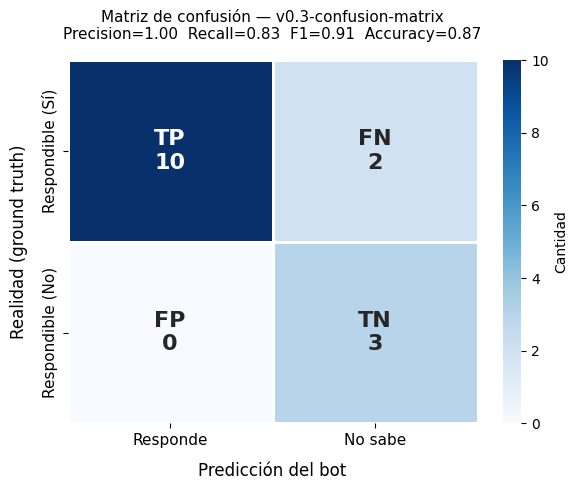

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Datos de la matriz de confusión ──────────────────────────────────
cm = entry["metrics_summary"]["confusion_matrix"]
matrix = np.array([[cm["tp"], cm["fn"]],
                   [cm["fp"], cm["tn"]]])

labels = np.array([[f"TP\n{cm['tp']}", f"FN\n{cm['fn']}"],
                   [f"FP\n{cm['fp']}", f"TN\n{cm['tn']}"]])

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    matrix,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=True,
    cbar_kws={"label": "Cantidad"},
    xticklabels=["Responde", "No sabe"],
    yticklabels=["Respondible (Sí)", "Respondible (No)"],
    linewidths=2,
    linecolor="white",
    annot_kws={"size": 16, "weight": "bold"},
    ax=ax,
)

ax.set_xlabel("Predicción del bot", fontsize=12, labelpad=10)
ax.set_ylabel("Realidad (ground truth)", fontsize=12, labelpad=10)
ax.set_title(
    f"Matriz de confusión — {entry['version']}\n"
    f"Precision={entry['metrics_summary']['precision']:.2f}  "
    f"Recall={entry['metrics_summary']['recall']:.2f}  "
    f"F1={entry['metrics_summary']['f1']:.2f}  "
    f"Accuracy={entry['metrics_summary']['accuracy']:.2f}",
    fontsize=11,
    pad=15,
)
ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()